In [2]:
import numpy as np
import pandas as pd

In [3]:
app_record = pd.read_csv("application_record.csv")

In [4]:
app_record.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
credit_record = pd.read_csv("credit_record.csv")

In [6]:
credit_record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## Merging Datasets

In [10]:
print("Unique IDs in application_record:", app_record['ID'].nunique())
print("Total rows in application_record:", app_record.shape[0])

print("Unique IDs in credit_record:", credit_record['ID'].nunique())
print("Total rows in credit_record:", credit_record.shape[0])

Unique IDs in application_record: 438510
Total rows in application_record: 438557
Unique IDs in credit_record: 45985
Total rows in credit_record: 1048575


In [17]:
# Droping credit_record duplicates
credit_deduped = credit_record.drop_duplicates(subset="ID", keep="first")

In [18]:
credit_merged = credit_deduped.merge(app_record, on="ID", how="inner")

In [19]:
credit_merged.head()

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,0,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,0,C,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,0,0,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,-22,X,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [20]:
credit_merged.shape

(36457, 20)

### Assigning race based on income quartile

In [26]:
customer_df = credit_merged.copy()

In [27]:
np.random.seed(42)

# Assign race based on income quartile
# This reflects SA's historically unequal income distribution
# Source: Stats SA income inequality data

def assign_race_by_income(row):
    income = row['AMT_INCOME_TOTAL']
    
    if income <= income_quartiles[0.25]:
        # Lowest income bracket — majority Black, fewer White
        return np.random.choice(
            ['Black', 'Coloured', 'Indian', 'White'],
            p=[0.78, 0.12, 0.04, 0.06]
        )
    elif income <= income_quartiles[0.50]:
        # Lower middle income
        return np.random.choice(
            ['Black', 'Coloured', 'Indian', 'White'],
            p=[0.72, 0.11, 0.05, 0.12]
        )
    elif income <= income_quartiles[0.75]:
        # Upper middle income
        return np.random.choice(
            ['Black', 'Coloured', 'Indian', 'White'],
            p=[0.58, 0.09, 0.06, 0.27]
        )
    else:
        # Highest income bracket — more White and Indian
        return np.random.choice(
            ['Black', 'Coloured', 'Indian', 'White'],
            p=[0.38, 0.07, 0.08, 0.47]
        )

customer_df['RACE'] = customer_df.apply(assign_race_by_income, axis=1)

### Building risk score from proxy variables

In [28]:
# Each variable contributes points to a risk score
# Higher score = higher risk

# Start everyone at zero
customer_df['RISK_SCORE'] = 0

# --- Income (lower income = higher risk) ---
# We use quartiles so it's relative to the dataset
income_quartiles = customer_df['AMT_INCOME_TOTAL'].quantile([0.25, 0.50, 0.75])

customer_df['RISK_SCORE'] += np.where(
    customer_df['AMT_INCOME_TOTAL'] <= income_quartiles[0.25], 3,  # lowest quartile
    np.where(
        customer_df['AMT_INCOME_TOTAL'] <= income_quartiles[0.50], 2,  # second quartile
        np.where(
            customer_df['AMT_INCOME_TOTAL'] <= income_quartiles[0.75], 1,  # third quartile
            0  # highest quartile
        )
    )
)

# --- Employment stability ---
# DAYS_EMPLOYED is negative for employed people
# Positive values mean currently unemployed
customer_df['RISK_SCORE'] += np.where(
    customer_df['DAYS_EMPLOYED'] > 0, 4,   # unemployed — highest risk
    np.where(
        customer_df['DAYS_EMPLOYED'] > -365, 2,   # employed less than 1 year
        np.where(
            customer_df['DAYS_EMPLOYED'] > -1825, 1,  # 1 to 5 years
            0   # more than 5 years — most stable
        )
    )
)

# --- Housing type ---
housing_risk = {
    'Rented apartment': 2,
    'With parents': 2,
    'Municipal apartment': 1,
    'Co-op apartment': 1,
    'House / apartment': 0,
    'Office apartment': 1
}
customer_df['RISK_SCORE'] += customer_df['NAME_HOUSING_TYPE'].map(housing_risk).fillna(1)

# --- Education level ---
education_risk = {
    'Lower secondary': 3,
    'Secondary / secondary special': 2,
    'Incomplete higher': 1,
    'Higher education': 0,
    'Academic degree': 0
}
customer_df['RISK_SCORE'] += customer_df['NAME_EDUCATION_TYPE'].map(education_risk).fillna(2)

# --- Property ownership ---
# Owning property = financial stability = lower risk
customer_df['RISK_SCORE'] += np.where(customer_df['FLAG_OWN_REALTY'] == 'Y', 0, 1)

# --- Car ownership ---
customer_df['RISK_SCORE'] += np.where(customer_df['FLAG_OWN_CAR'] == 'Y', 0, 1)

print("Risk score distribution:")
print(customer_df['RISK_SCORE'].describe())
print("\nRisk score value counts:")
print(customer_df['RISK_SCORE'].value_counts().sort_index())

Risk score distribution:
count    36457.000000
mean         5.235839
std          2.524818
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         13.000000
Name: RISK_SCORE, dtype: float64

Risk score value counts:
RISK_SCORE
0      590
1     1687
2     2896
3     4321
4     5449
5     5529
6     5388
7     3811
8     2392
9     1813
10    1915
11     604
12      58
13       4
Name: count, dtype: int64


### Converting score to bad risk label

In [29]:
# Threshold — anyone above this score is classified as high risk
# We use the 70th percentile so roughly 30% are classified bad risk
threshold = customer_df['RISK_SCORE'].quantile(0.70)

customer_df['BAD_RISK'] = (customer_df['RISK_SCORE'] > threshold).astype(int)

print(f"\nThreshold score: {threshold}")
print("\nBAD_RISK distribution:")
print(customer_df['BAD_RISK'].value_counts())
print("\nBad risk rate:", round(customer_df['BAD_RISK'].mean() * 100, 1), "%")


Threshold score: 6.0

BAD_RISK distribution:
BAD_RISK
0    25860
1    10597
Name: count, dtype: int64

Bad risk rate: 29.1 %


### Checking racial disparity

In [31]:
race_risk = customer_df.groupby('RACE')['BAD_RISK'].mean().round(3) * 100

print("\nBad risk rate by race (%):")
print(race_risk.sort_values(ascending=False))


Bad risk rate by race (%):
RACE
Black       33.7
Coloured    32.5
Indian      23.1
White       15.9
Name: BAD_RISK, dtype: float64


In [32]:
# Bad risk rates per group
black_rate = customer_df[customer_df['RACE'] == 'Black']['BAD_RISK'].mean()
white_rate = customer_df[customer_df['RACE'] == 'White']['BAD_RISK'].mean()
coloured_rate = customer_df[customer_df['RACE'] == 'Coloured']['BAD_RISK'].mean()
indian_rate = customer_df[customer_df['RACE'] == 'Indian']['BAD_RISK'].mean()

# Approval rates (inverse of bad risk)
black_approval = 1 - black_rate
white_approval = 1 - white_rate
coloured_approval = 1 - coloured_rate
indian_approval = 1 - indian_rate

print("=== APPROVAL RATES ===")
print(f"Black:    {black_approval*100:.1f}%")
print(f"Coloured: {coloured_approval*100:.1f}%")
print(f"Indian:   {indian_approval*100:.1f}%")
print(f"White:    {white_approval*100:.1f}%")

# DIR — Black vs White (most disadvantaged vs most advantaged)
DIR = black_approval / white_approval
print(f"\n=== DISPARATE IMPACT RATIO ===")
print(f"DIR (Black vs White): {DIR:.3f}")
print(f"Fair threshold: 0.800")
print(f"Result: {'FAIR' if DIR >= 0.8 else 'BIASED — below fair threshold'}")

# SPD
SPD = white_approval - black_approval
print(f"\n=== STATISTICAL PARITY DIFFERENCE ===")
print(f"SPD (White - Black): {SPD*100:.1f} percentage points")
print(f"Fair threshold: 0")
print(f"Result: {'FAIR' if SPD == 0 else 'BIASED — gap exists'}")

=== APPROVAL RATES ===
Black:    66.3%
Coloured: 67.5%
Indian:   76.9%
White:    84.1%

=== DISPARATE IMPACT RATIO ===
DIR (Black vs White): 0.788
Fair threshold: 0.800
Result: BIASED — below fair threshold

=== STATISTICAL PARITY DIFFERENCE ===
SPD (White - Black): 17.8 percentage points
Fair threshold: 0
Result: BIASED — gap exists


### Approval Rate by Race

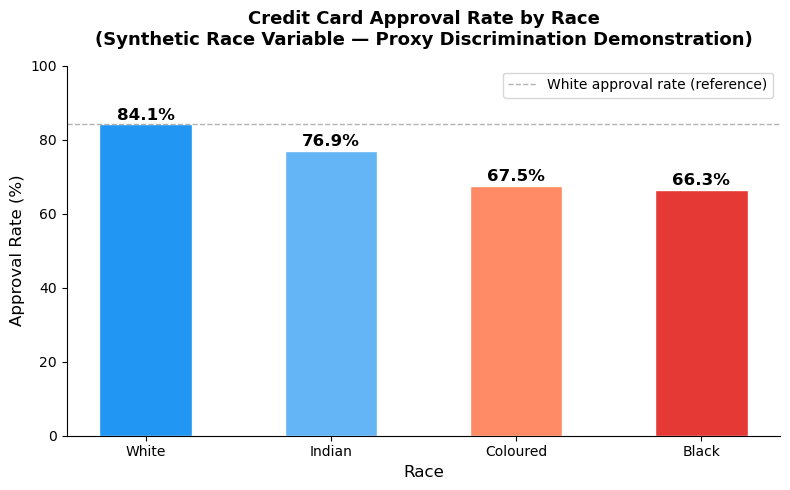

Chart 1 saved


In [34]:


# Calculate approval rates
approval_by_race = customer_df.groupby('RACE')['BAD_RISK'].apply(
    lambda x: (1 - x.mean()) * 100
).reset_index()
approval_by_race.columns = ['RACE', 'APPROVAL_RATE']
approval_by_race = approval_by_race.sort_values('APPROVAL_RATE', ascending=False)

# Define colors — highlight Black and White for contrast
colors = {
    'White': '#2196F3',
    'Indian': '#64B5F6',
    'Coloured': '#FF8A65',
    'Black': '#E53935'
}
bar_colors = [colors[r] for r in approval_by_race['RACE']]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    approval_by_race['RACE'],
    approval_by_race['APPROVAL_RATE'],
    color=bar_colors,
    width=0.5,
    edgecolor='white'
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

# Add a reference line at White approval rate
ax.axhline(
    y=approval_by_race[approval_by_race['RACE'] == 'White']['APPROVAL_RATE'].values[0],
    color='grey', linestyle='--', linewidth=1, alpha=0.6,
    label='White approval rate (reference)'
)

ax.set_title('Credit Card Approval Rate by Race\n(Synthetic Race Variable — Proxy Discrimination Demonstration)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Race', fontsize=12)
ax.set_ylabel('Approval Rate (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_approval_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

### Fairness Threshold

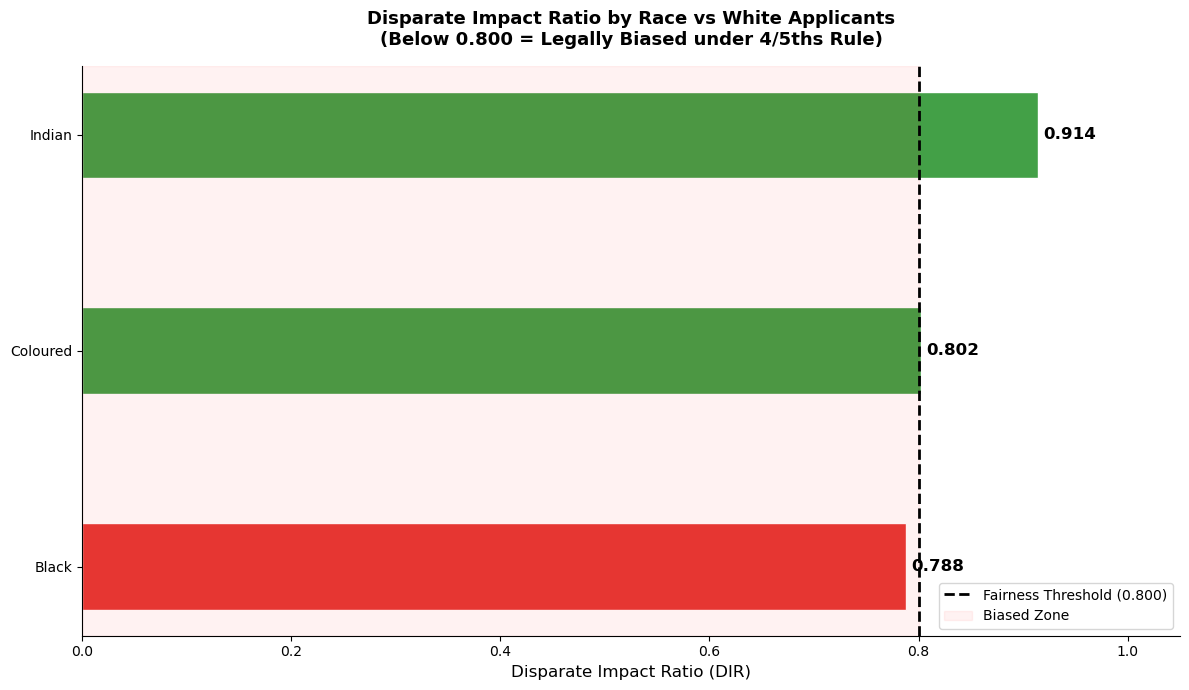

Chart 2 saved


In [37]:
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate DIR for each group vs White
races = ['Black', 'Coloured', 'Indian']
dirs = []
for race in races:
    rate = customer_df[customer_df['RACE'] == race]['BAD_RISK'].mean()
    white_rate = customer_df[customer_df['RACE'] == 'White']['BAD_RISK'].mean()
    approval = 1 - rate
    white_approval = 1 - white_rate
    dirs.append(round(approval / white_approval, 3))

# Color bars red if below threshold, green if above
bar_colors = ['#E53935' if d < 0.8 else '#43A047' for d in dirs]

bars = ax.barh(races, dirs, color=bar_colors, height=0.4, edgecolor='white')

# Add value labels
for bar, val in zip(bars, dirs):
    ax.text(
        val + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', fontsize=12, fontweight='bold'
    )

# Fairness threshold line
ax.axvline(
    x=0.8,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Fairness Threshold (0.800)'
)

# Shade the biased region
ax.axvspan(0, 0.8, alpha=0.05, color='red', label='Biased Zone')

ax.set_title('Disparate Impact Ratio by Race vs White Applicants\n(Below 0.800 = Legally Biased under 4/5ths Rule)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Disparate Impact Ratio (DIR)', fontsize=12)
ax.set_xlim(0, 1.05)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_dir_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

### Income Distribution By Race

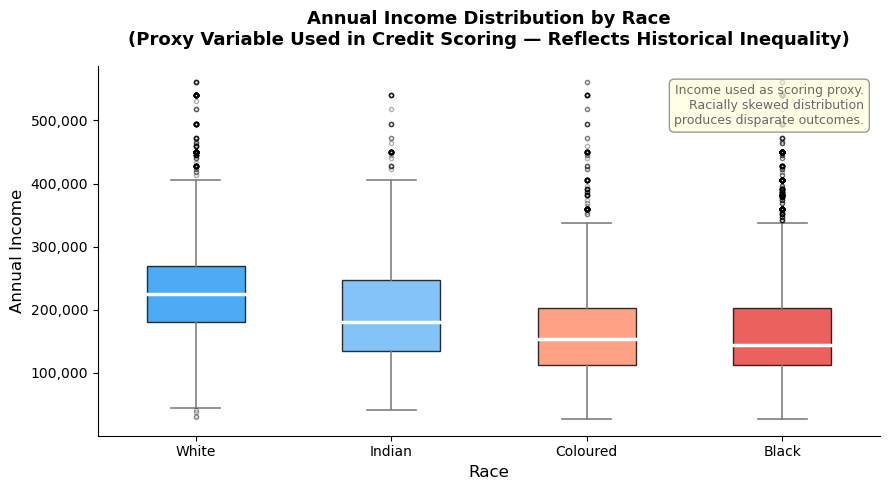

Chart 3 saved


In [38]:
import matplotlib.patches as mpatches

# Cap income at 99th percentile to remove extreme outliers
income_cap = customer_df['AMT_INCOME_TOTAL'].quantile(0.99)
plot_df = customer_df[customer_df['AMT_INCOME_TOTAL'] <= income_cap].copy()

# Order races by median income descending
race_order = (
    plot_df.groupby('RACE')['AMT_INCOME_TOTAL']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Build data groups in order
data_by_race = [
    plot_df[plot_df['RACE'] == race]['AMT_INCOME_TOTAL'].values
    for race in race_order
]

fig, ax = plt.subplots(figsize=(9, 5))

box_colors = ['#2196F3', '#64B5F6', '#FF8A65', '#E53935']

bp = ax.boxplot(
    data_by_race,
    patch_artist=True,
    labels=race_order,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2.5)
)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for whisker in bp['whiskers']:
    whisker.set(color='grey', linewidth=1.2)
for cap in bp['caps']:
    cap.set(color='grey', linewidth=1.2)
for flier in bp['fliers']:
    flier.set(marker='o', color='grey', alpha=0.3, markersize=3)

ax.set_title('Annual Income Distribution by Race\n(Proxy Variable Used in Credit Scoring — Reflects Historical Inequality)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Race', fontsize=12)
ax.set_ylabel('Annual Income', fontsize=12)

# Format y axis with commas
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotation explaining the link
ax.annotate(
    'Income used as scoring proxy.\nRacially skewed distribution\nproduces disparate outcomes.',
    xy=(0.98, 0.95), xycoords='axes fraction',
    fontsize=9, color='dimgrey',
    ha='right', va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='grey', alpha=0.8)
)

plt.tight_layout()
plt.savefig('chart3_income_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

# Explanation of results

Approval rates:

White applicants get approved at 84.1%
Black applicants get approved at only 66.3%
That is a 17.8 percentage point gap between the most and least advantaged group

DIR of 0.788:

This falls below the 0.8 fairness threshold
Meaning for every 10 White applicants approved, only 7.9 Black applicants are approved
This is the legal definition of disparate impact under the 4/5ths rule


SPD of 17.8 percentage points:

In a perfectly fair system this would be zero
17.8 is a substantial gap


# Story We can Tell

## How Proxy Discrimination Works at the company

**Step 1 — The Scoring Inputs**
The Company uses income, housing and employment to build credit profiles.
These variables appear financially neutral and race-blind.

**Step 2 — The Hidden Correlation**
These variables are racially skewed due to apartheid's legacy.
Apartheid systematically denied Black South Africans access to:
- Quality education and skilled employment
- Property ownership through the Group Areas Act
- Formal banking and credit institutions
- Equal wages through job reservation policies

The result is that decades later, income and wealth remain
racially distributed — not because of individual behaviour,
but because of structural historical exclusion.

**Step 3 — The Disparate Outcome**
The scoring system produces a 17.8 percentage point approval
gap between Black and White applicants.
DIR = 0.788 — legally below the 0.8 fairness threshold.
Race was never used as an input. The disparity emerged anyway.

**Step 4 — The Data Product**
The company sells these biased profiles to lenders, insurers
and retailers as objective credit risk assessments.
The bias is invisible to the buyer — laundered through numbers.

**Step 5 — The Real World Impact**
Lenders deny Black applicants at higher rates based on
the profiles they purchased from the organization.

**Step 6 — The Feedback Loop**
Denied applicants cannot build a positive credit history.
The next time their data is scored, the profile looks
the same or worse — confirming the original assessment.

**Step 7 — The Loop Continues**
The system reinforces itself with every cycle.
No individual in the chain made a consciously discriminatory
decision. The discrimination is structural and automated —
which is precisely what makes it so dangerous.

# Metaphor

### Viewing the world through shattered, rose-tinted glass.

#### When decisions are made using a distorted lens, the outcomes may appear efficient and profitable, but they can systematically favour certain groups while disadvantaging others

#### Maps to: credit scoring based on socio-economic proxies can unintentionally reproduce historical inequalities in modern financial decisions.

# References

[1] M. Ahmed, “Credit Card Approval Prediction Notebook Dataset,” Kaggle. [Online]. Available: https://www.kaggle.com/code/mennaahmed016/credit-card-approval-prediction-notebook/input
. Accessed: Mar. 5, 2026.

[2] F. Martínez-Plumed et al., “CRISP-DM twenty years later: From data mining processes to data science trajectories,” IEEE Transactions on Knowledge and Data Engineering, vol. 33, no. 8, pp. 3048–3061, Aug. 2021.

[3] OpenAI, “ChatGPT,” OpenAI. [Online]. Available: https://chat.openai.com
. Accessed: Mar. 5, 2026.

[4] Statistics South Africa, “General Household Survey 2022,” Stats SA. [Online]. Available: https://isibaloweb.statssa.gov.za/pages/surveys/pss/ghs/2022/ghs2022.php
. Accessed: Mar. 6, 2026.

[5] F. Kamiran and T. Calders, “Data preprocessing techniques for classification without discrimination,” Knowledge and Information Systems, vol. 33, no. 1, pp. 1–33, 2012. [Online]. Available: https://doi.org/10.1007/s10115-011-0463-8
. Accessed: Mar. 9, 2026.

[6] N. Bostrom and E. Yudkowsky, “The ethics of artificial intelligence,” in The Cambridge Handbook of Artificial Intelligence, W. Ramsey and K. Frankish, Eds. Cambridge, U.K.: Cambridge University Press, 2014, pp. 316–334. [Online]. Available: https://www.cambridge.org/core/books/cambridge-handbook-of-artificial-intelligence/ethics-of-artificial-intelligence
. Accessed: Mar. 8, 2026.

